# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np

In [2]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] =14
matplotlib.rcParams['figure.figsize']= (10,6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [4]:
loan_df = pd.read_csv(r"C:\PROJECTS\NEW\To_work_on\LOAN\loan_data_set.csv")
loan_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [5]:
loan_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
loan_df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

# 3. Imputing Missing Data

In [8]:
loan_df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
loan_df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [10]:
loan_df['Married']= loan_df['Married'].str.strip()
loan_df['Married'] = loan_df['Married'].map({'Yes':1,'No':0})
loan_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,0.0,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,1.0,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,1.0,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,1.0,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,0.0,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0.0,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,1.0,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,1.0,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,1.0,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [11]:
loan_df['Self_Employed']= loan_df['Self_Employed'].str.strip()
loan_df['Self_Employed'] = loan_df['Self_Employed'].map({'Yes':1,'No':0})
loan_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,0.0,0,Graduate,0.0,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,1.0,1,Graduate,0.0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,1.0,0,Graduate,1.0,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,1.0,0,Not Graduate,0.0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,0.0,0,Graduate,0.0,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0.0,0,Graduate,0.0,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,1.0,3+,Graduate,0.0,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,1.0,1,Graduate,0.0,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,1.0,2,Graduate,0.0,7583,0.0,187.0,360.0,1.0,Urban,Y


In [12]:
loan_df['Gender'] = loan_df['Gender'].str.strip()
loan_df['Gender'] = loan_df['Gender'].map({'Male':1,'Female':0})
loan_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1.0,0.0,0,Graduate,0.0,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,1.0,1.0,1,Graduate,0.0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,1.0,1.0,0,Graduate,1.0,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,1.0,1.0,0,Not Graduate,0.0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,1.0,0.0,0,Graduate,0.0,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0.0,0.0,0,Graduate,0.0,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,1.0,1.0,3+,Graduate,0.0,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,1.0,1.0,1,Graduate,0.0,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,1.0,1.0,2,Graduate,0.0,7583,0.0,187.0,360.0,1.0,Urban,Y


In [13]:
loan_df['Education'] = loan_df['Education'].str.strip()
loan_df['Education'] = loan_df['Education'].map({'Graduate':1,'Not Graduate':0})
loan_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1.0,0.0,0,1,0.0,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,1.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,1.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,1.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,1.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0.0,0.0,0,1,0.0,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,1.0,1.0,3+,1,0.0,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,1.0,1.0,1,1,0.0,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,1.0,1.0,2,1,0.0,7583,0.0,187.0,360.0,1.0,Urban,Y


In [14]:
loan_df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [15]:
loan_df['Married'] = loan_df['Married'].fillna(0)


In [16]:
loan_df['Credit_History'] = loan_df['Credit_History'].fillna(0)

In [17]:
loan_df['Self_Employed'] = loan_df['Self_Employed'].fillna(0)

In [18]:
mean_Loan_Amount_Term = loan_df['Loan_Amount_Term'].mean()
loan_df['Loan_Amount_Term'] = loan_df['Loan_Amount_Term'].fillna(mean_Loan_Amount_Term)

In [19]:
mean_Loan_Amount_Term = loan_df['Loan_Amount_Term'].mean()
mean_Loan_Amount_Term

np.float64(342.0)

In [20]:
mode_gender = loan_df['Gender'].mode()[0]
mode_gender

np.float64(1.0)

In [21]:
loan_df['Gender'] = loan_df['Gender'].fillna(mode_gender)
loan_df['Gender'].fillna(mode_gender)

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    0.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Gender, Length: 614, dtype: float64

In [22]:
# loan_df['Gender'].fillna(1)

In [23]:
loan_df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents           15
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [24]:
mean_Loan_Amount = loan_df['LoanAmount'].mean()
loan_df['LoanAmount'] = loan_df['LoanAmount'].fillna(mean_Loan_Amount)

In [25]:
mode_Dependents = loan_df['Dependents'].mode()[0]
mode_Dependents
loan_df['Dependents'] = loan_df['Dependents'].fillna(mode_Dependents)


# 3. Training, Validation and Test Sets

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
train_val_df, test_df = train_test_split(loan_df, test_size = 0.2, random_state = 42)
train_df, val_df = train_test_split(train_val_df, test_size= 0.25, random_state = 42)

In [28]:
print('train_df.shape: ', train_df.shape)
print('val_df.shape: ', val_df.shape)
print('test_df.shape: ', test_df.shape)

train_df.shape:  (368, 13)
val_df.shape:  (123, 13)
test_df.shape:  (123, 13)


# 4. Identifying Input and Target Columns

In [29]:
input_cols = list(train_df.columns)[1:12]
input_cols

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area']

In [30]:
target_col = 'Loan_Status'
target_col

'Loan_Status'

In [31]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [32]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [33]:
test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

In [34]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()

In [35]:
train_inputs[numeric_cols]

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
254,1.0,0.0,1,1.0,16250,0.0,192.000000,360.0,0.0
314,1.0,1.0,1,0.0,2473,1843.0,159.000000,360.0,1.0
168,1.0,0.0,1,0.0,2237,0.0,63.000000,480.0,0.0
305,1.0,0.0,0,0.0,2000,0.0,146.412162,360.0,1.0
380,1.0,1.0,1,0.0,3333,2500.0,128.000000,360.0,1.0
...,...,...,...,...,...,...,...,...,...
522,1.0,1.0,1,1.0,5677,1424.0,100.000000,360.0,1.0
541,0.0,0.0,1,0.0,2138,0.0,99.000000,360.0,0.0
236,1.0,1.0,1,0.0,5746,0.0,255.000000,360.0,0.0
205,0.0,0.0,0,0.0,4408,0.0,120.000000,360.0,1.0


In [36]:
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [37]:
train_inputs[categorical_cols]

,Dependents,Property_Area
254,0,Urban
314,0,Rural
168,0,Semiurban
305,0,Urban
380,0,Semiurban
...,...,...
522,3+,Rural
541,0,Semiurban
236,0,Urban
205,0,Semiurban


In [38]:
loan_df['Property_Area'].dtypes

dtype('O')

In [39]:
loan_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1.0,0.0,0,1,0.0,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,1.0,1.0,1,1,0.0,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,1.0,1.0,0,1,1.0,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,1.0,1.0,0,0,0.0,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,1.0,0.0,0,1,0.0,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0.0,0.0,0,1,0.0,2900,0.0,71.000000,360.0,1.0,Rural,Y
610,LP002979,1.0,1.0,3+,1,0.0,4106,0.0,40.000000,180.0,1.0,Rural,Y
611,LP002983,1.0,1.0,1,1,0.0,8072,240.0,253.000000,360.0,1.0,Urban,Y
612,LP002984,1.0,1.0,2,1,0.0,7583,0.0,187.000000,360.0,1.0,Urban,Y


In [40]:
train_inputs

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
254,1.0,0.0,0,1,1.0,16250,0.0,192.000000,360.0,0.0,Urban
314,1.0,1.0,0,1,0.0,2473,1843.0,159.000000,360.0,1.0,Rural
168,1.0,0.0,0,1,0.0,2237,0.0,63.000000,480.0,0.0,Semiurban
305,1.0,0.0,0,0,0.0,2000,0.0,146.412162,360.0,1.0,Urban
380,1.0,1.0,0,1,0.0,3333,2500.0,128.000000,360.0,1.0,Semiurban
...,...,...,...,...,...,...,...,...,...,...,...
522,1.0,1.0,3+,1,1.0,5677,1424.0,100.000000,360.0,1.0,Rural
541,0.0,0.0,0,1,0.0,2138,0.0,99.000000,360.0,0.0,Semiurban
236,1.0,1.0,0,1,0.0,5746,0.0,255.000000,360.0,0.0,Urban
205,0.0,0.0,0,0,0.0,4408,0.0,120.000000,360.0,1.0,Semiurban


# 5. Scaling the Data

In [41]:
from sklearn.preprocessing import MinMaxScaler

In [42]:
scaler = MinMaxScaler()

In [43]:
loan_df[numeric_cols]

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1.0,0.0,1,0.0,5849,0.0,146.412162,360.0,1.0
1,1.0,1.0,1,0.0,4583,1508.0,128.000000,360.0,1.0
2,1.0,1.0,1,1.0,3000,0.0,66.000000,360.0,1.0
3,1.0,1.0,0,0.0,2583,2358.0,120.000000,360.0,1.0
4,1.0,0.0,1,0.0,6000,0.0,141.000000,360.0,1.0
...,...,...,...,...,...,...,...,...,...
609,0.0,0.0,1,0.0,2900,0.0,71.000000,360.0,1.0
610,1.0,1.0,1,0.0,4106,0.0,40.000000,180.0,1.0
611,1.0,1.0,1,0.0,8072,240.0,253.000000,360.0,1.0
612,1.0,1.0,1,0.0,7583,0.0,187.000000,360.0,1.0


In [44]:
scaler.fit(loan_df[numeric_cols])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [45]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])


In [46]:
train_inputs

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
254,1.0,0.0,0,1.0,1.0,0.199134,0.000000,0.264834,0.74359,0.0,Urban
314,1.0,1.0,0,1.0,0.0,0.028732,0.044232,0.217077,0.74359,1.0,Rural
168,1.0,0.0,0,1.0,0.0,0.025813,0.000000,0.078148,1.00000,0.0,Semiurban
305,1.0,0.0,0,0.0,0.0,0.022882,0.000000,0.198860,0.74359,1.0,Urban
380,1.0,1.0,0,1.0,0.0,0.039369,0.060000,0.172214,0.74359,1.0,Semiurban
...,...,...,...,...,...,...,...,...,...,...,...
522,1.0,1.0,3+,1.0,1.0,0.068361,0.034176,0.131693,0.74359,1.0,Rural
541,0.0,0.0,0,1.0,0.0,0.024589,0.000000,0.130246,0.74359,0.0,Semiurban
236,1.0,1.0,0,1.0,0.0,0.069215,0.000000,0.356006,0.74359,0.0,Urban
205,0.0,0.0,0,0.0,0.0,0.052665,0.000000,0.160637,0.74359,1.0,Semiurban


# 6. OneHot Encoding

In [47]:
from sklearn.preprocessing import OneHotEncoder

In [48]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown = 'ignore')

In [49]:
encoder.fit(loan_df[categorical_cols])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [50]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [51]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])


In [52]:
train_inputs[encoded_cols]

,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
254,1.0,0.0,0.0,0.0,0.0,0.0,1.0
314,1.0,0.0,0.0,0.0,1.0,0.0,0.0
168,1.0,0.0,0.0,0.0,0.0,1.0,0.0
305,1.0,0.0,0.0,0.0,0.0,0.0,1.0
380,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...
522,0.0,0.0,0.0,1.0,1.0,0.0,0.0
541,1.0,0.0,0.0,0.0,0.0,1.0,0.0
236,1.0,0.0,0.0,0.0,0.0,0.0,1.0
205,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [287]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

# 7. Training Models

## 7.1 Logistic Regression
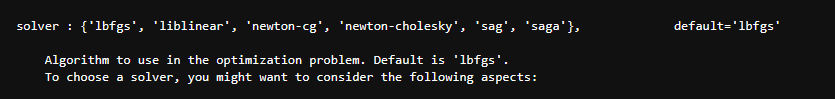

In [288]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression( solver = 'liblinear', max_iter = 500, random_state=1)
model.fit(X_train, train_targets)
train_preds = model.predict(X_train)

In [289]:
#?LogisticRegression

In [290]:

train_probs = model.predict_proba(X_train)
model.classes_

array(['N', 'Y'], dtype=object)

In [291]:
train_targets

254    N
314    N
168    N
305    N
380    Y
      ..
522    Y
541    N
236    N
205    Y
271    Y
Name: Loan_Status, Length: 368, dtype: object

In [292]:
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

In [282]:
from sklearn.metrics import accuracy_score
X_acc = accuracy_score(train_targets, train_preds)
val_acc = accuracy_score(val_targets, val_preds)
test_acc = accuracy_score(test_targets, test_preds)
print('Train Accuracy :',X_acc)
print('Validation Accuracy :',val_acc)
print('Test Accuracy :', test_acc)

Train Accuracy : 0.782608695652174
Validation Accuracy : 0.7317073170731707
Test Accuracy : 0.7723577235772358


In [283]:
from sklearn.metrics import confusion_matrix

In [284]:
confusion_matrix(train_targets, train_preds, normalize = 'true')

array([[0.48623853, 0.51376147],
       [0.09266409, 0.90733591]])

In [285]:
def predict_and_plot(inputs, targets, name = ''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy*100))

    cf = confusion_matrix(targets,preds, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))

    return preds

Accuracy: 77.24%


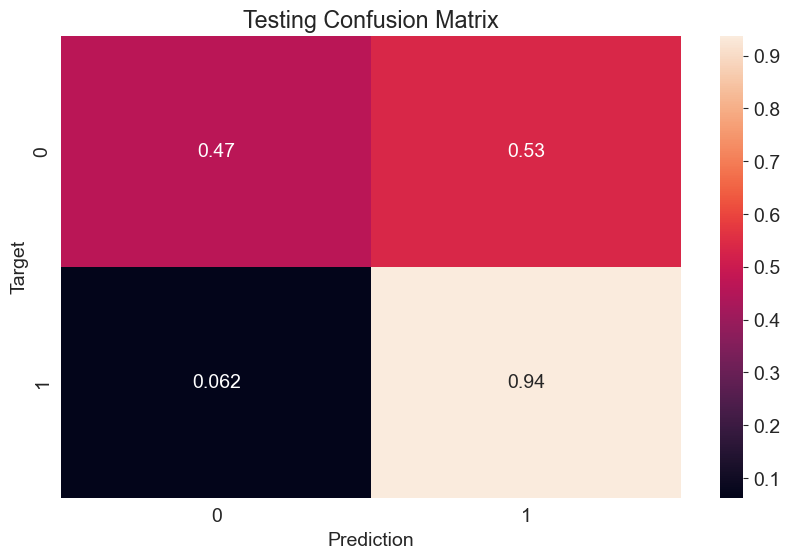

In [286]:
test_preds = predict_and_plot(X_test, test_targets, 'Testing')

## 7.2 Decision Trees

In [68]:
from sklearn.tree import DecisionTreeClassifier

In [146]:
?DecisionTreeClassifier

Init signature:
DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Docstring:     
A decision tree classifier.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"gini", "entropy", "log_loss"}, default="gini"
    The function to measure the quality of a split. Supported criteria are
    "gini" for the Gini impurity and "log_loss" and "entropy" both for the
    Shannon information gain, see :ref:`tree_mathematical_formulation`.

splitter : {"best", "random"}, default="best"
    The strategy used to choose the split at each node. Supported
    strategies are "best" to choose the best split and "random" to choose
    the best random split.

max_depth : int, default=None

In [361]:
model = DecisionTreeClassifier(max_depth = 4,max_leaf_nodes = 4, random_state = 42)

In [379]:
model.fit(X_train,train_targets)
train_preds = model.predict(X_train)
from sklearn.metrics import accuracy_score, confusion_matrix
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)


In [381]:
Train_acc = accuracy_score(train_preds, train_targets)
Val_acc = accuracy_score(val_preds, val_targets)
Test_acc = accuracy_score(test_preds, test_targets)
print('Train Accuracy :',Train_acc)
print('Validation Accuracy :',Val_acc)
print('Test Accuracy :', Test_acc)

Train Accuracy : 0.7989130434782609
Validation Accuracy : 0.7154471544715447
Test Accuracy : 0.7723577235772358


## 7.3 Random Forests

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [383]:
?RandomForestClassifier

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

In [413]:
model = RandomForestClassifier(n_estimators = 1000, max_leaf_nodes= 6, random_state = 42)
model.fit(X_train,train_targets)

,n_estimators,1000
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,6
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [414]:
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

In [415]:
RF_train_acc = accuracy_score(train_preds, train_targets)
RF_val_acc = accuracy_score(val_preds, val_targets)
print('Train Accuracy :',RF_train_acc)
print('Validation Accuracy :',RF_val_acc)


Train Accuracy : 0.8233695652173914
Validation Accuracy : 0.7073170731707317
